In [54]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn           as sns
import datetime
import os
import re
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [65]:
def clean_model_name(name):
    """
    모델명 끝의 개인 이니셜(_abc, _ejm 등)을 제거하는 함수.
    - 언더바 + 3~5 영문자 → 제거
    """
    return re.sub(r'_[A-Za-z]{3,5}$', '', name)


In [68]:
# model_metrics_graph4CCF ##################
def model_metrics_graph4CCF(
    df_results, 
    title='모델별 성능 지표 비교', 
    figsize=(20, 10),
    top_n=None,          
    sort_by='F1',
    output_dir="../report",
    create_top10=True,
    create_boxplot=True,
    create_radar=True,
    create_heatmap=True
):
    """
    모델 지표 기반 그래프 생성 및 분석 함수 (리팩토링 버전)

    지표만으로 생성 가능한 그래프:
      - Top10 F1 Bar Plot
      - 전체 지표 Boxplot
      - Radar Chart (Top5)
      - Heatmap (모델 vs 지표)

    Parameters:
    -----------
    df_results : pd.DataFrame
        columns = ['model_name','AUC','정밀도','재현율','F1']
    top_n : int
        sort_by 기준 상위 N개 선택
    sort_by : str
        정렬 기준 ('F1','AUC','정밀도','재현율')
    output_dir : str
        그래프 저장 위치
    create_top10, create_boxplot, create_radar, create_heatmap : bool
        생성할 그래프 선택 옵션
    """

    try:
        # -----------------------------------------
        # 1. 입력 체크 & 초기 세팅
        # -----------------------------------------
        if not isinstance(df_results, pd.DataFrame):
            raise ValueError("df_results는 pandas DataFrame이어야 합니다.")
        
        os.makedirs(output_dir, exist_ok=True)

        df_work = df_results.copy()
        
        # model_name cleanning
        if "model_name" in df_work.columns:
            df_work["model_name"] = df_work["model_name"].apply(clean_model_name)        

        # 정렬
        if sort_by in df_work.columns:
            df_work = df_work.sort_values(sort_by, ascending=False)
        else:
            print(f"⚠️ sort_by='{sort_by}'가 존재하지 않습니다. 정렬을 건너뜁니다.")

        # TopN 적용
        if top_n is not None:
            df_work = df_work.head(top_n)
            print(f"📊 상위 {top_n}개 모델 선택 (정렬 기준: {sort_by})")

        # model_name을 index로
        if "model_name" in df_work.columns:
            df_work = df_work.set_index("model_name")

        # 저장
        df_work.to_csv(f"{output_dir}/selected_metrics.csv", encoding="utf-8-sig")
        print(f"📁 선택된 지표 저장 완료 → {output_dir}/selected_metrics.csv")

        # -----------------------------------------
        # 2. 그래프 생성
        # -----------------------------------------

        # 2-1. Top10 Bar Chart
        if create_top10:
            plot_top10_f1(df_work, save_path=f"{output_dir}/top10_f1.png")
            print("📈 Top10 F1 Bar Plot 생성 완료")

        # 2-2. 전체 Boxplot
        if create_boxplot:
            plot_metric_boxplots(df_work, save_path=f"{output_dir}/metric_boxplot.png")
            print("📊 전체 지표 Boxplot 생성 완료")

        # 2-3. Radar Chart (Top5)
        if create_radar:
            plot_radar_chart(df_work, save_path=f"{output_dir}/radar_chart.png")
            print("🧭 Radar Chart 생성 완료")

        # 2-4. Heatmap
        if create_heatmap:
            plot_metric_heatmap(df_work, save_path=f"{output_dir}/metric_heatmap.png")
            print("🔥 Heatmap 생성 완료")

        # -----------------------------------------
        # 3. 통계 요약 출력
        # -----------------------------------------
        print("\n=== 지표별 통계 요약 ===")
        metrics = ['AUC','정밀도','재현율','F1']

        for metric in metrics:
            if metric in df_work.columns:
                print(f"\n[{metric}]")
                print(f"  최고  : {df_results[metric].max():.4f} ({df_results[metric].idxmax()})")
                print(f"  최저  : {df_results[metric].min():.4f} ({df_results[metric].idxmin()})")
                print(f"  평균  : {df_results[metric].mean():.4f}")
                print(f"  표준편차 : {df_results[metric].std():.4f}")

        return df_work

    except Exception as e:
        print(f"[에러 발생] {e}")
        import traceback
        traceback.print_exc()


In [58]:
def plot_top10_f1(df, save_path="../report/top10_f1.png"):
    df_top10 = df.sort_values("F1", ascending=False).head(10)

    plt.figure(figsize=(10,5))
    sns.barplot(data=df_top10, x="model_name", y="F1", palette="Blues_d")
    plt.title("F1 기준 Top 10 모델 성능 비교")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()


In [59]:
def plot_metric_boxplots(df, save_path="../report/metric_boxplot.png"):
    metrics = ['AUC', '정밀도', '재현율', 'F1']

    plt.figure(figsize=(10,6))
    sns.boxplot(data=df[metrics])
    plt.title("전체 모델 지표 분포(Boxplot)")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()


In [78]:
def plot_radar_chart(df, save_path="radar_chart.png", top_n=5):
    top5 = df.sort_values("F1", ascending=False).head(top_n)
    metrics = ["AUC", "정밀도", "재현율", "F1"]

    num_vars = len(metrics)
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, polar=True)

    plt.title(f"상위 {top_n}개 모델 Radar Chart", fontsize=14)
    plt.ylim(0.95, 1.01)

    for idx, row in top5.iterrows():
        values = row[metrics].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, marker='o', alpha=0.7, label=idx)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()




In [79]:
def plot_metric_heatmap(df, save_path="../report/metric_heatmap.png", top_n=10, sort_by="F1"):
    """
    모델별 성능 Heatmap을 생성 (상위 N개만 표시)

    Parameters:
    -----------
    df : DataFrame
        ['model_name','AUC','정밀도','재현율','F1'] 포함
    top_n : int
        상위 몇 개 모델을 heatmap에 표시할지
    sort_by : str
        정렬 기준 ('F1','AUC','정밀도','재현율')

    Returns:
    --------
    None
    """

    # model_name 정규화 (원하면 주석 제거)
    # df["model_name"] = df["model_name"].apply(clean_model_name)

    # 정렬
    df_sorted = df.sort_values(sort_by, ascending=False)

    # 상위 N개 선택
    df_top = df_sorted.head(top_n)

    # pivot 형태로 변환
    df_pivot = df_top[["AUC","F1","재현율","정밀도"]]


    plt.figure(figsize=(8, max(6, top_n * 0.5)))
    sns.heatmap(df_pivot, annot=False, cmap="Blues", cbar=True)
    plt.title(f"모델별 핵심 지표 Heatmap (Top {top_n}, 기준: {sort_by})")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close()

    print(f"🔥 Heatmap 저장 완료 → {save_path}")


In [62]:
# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
from utils.results_report  import load_results_to_df

In [ ]:
df_results = load_results_to_df('../results', sort_by='F1', ascending=False)


📊 상위 10개 모델 선택 (정렬 기준: F1)
📁 선택된 지표 저장 완료 → ../report/selected_metrics.csv


C:\Users\july1\AppData\Local\Temp\ipykernel_162484\892584165.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, x="model_name", y="F1", palette="Blues_d")


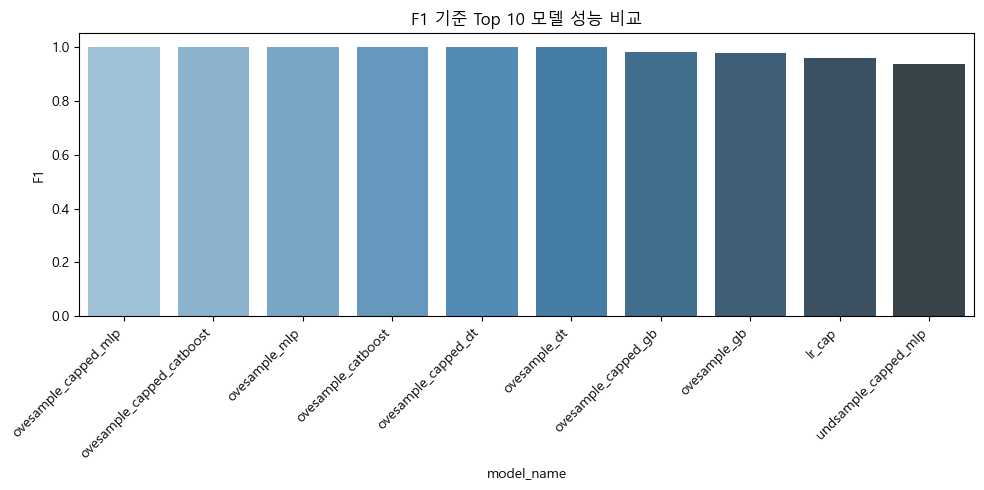

📈 Top10 F1 Bar Plot 생성 완료


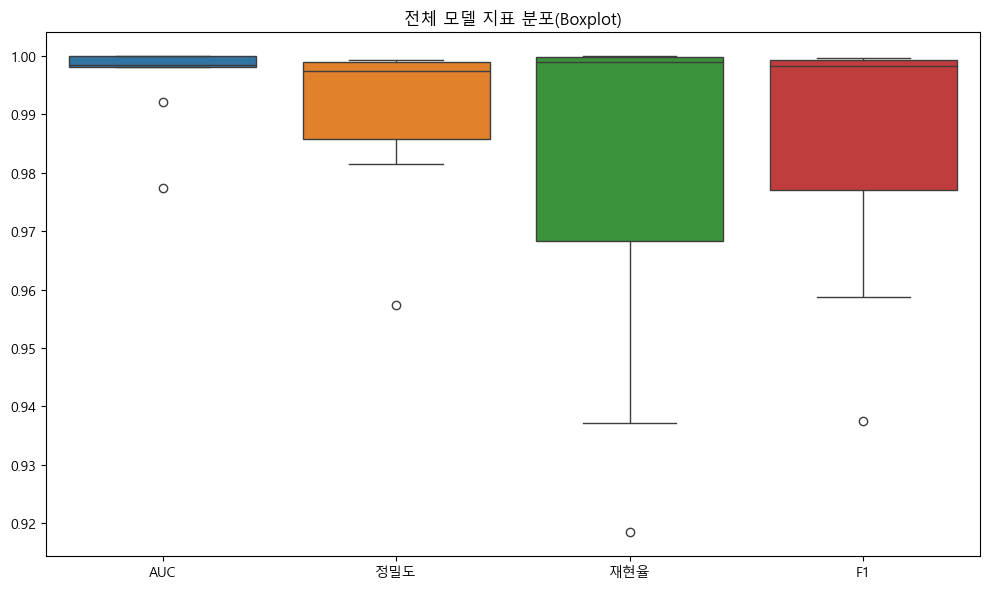

📊 전체 지표 Boxplot 생성 완료


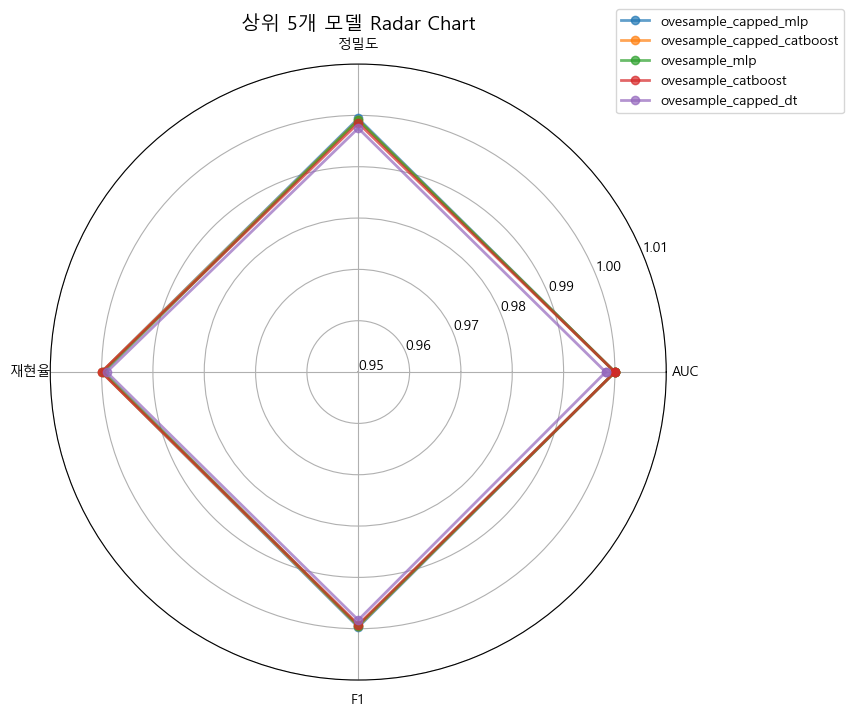

🧭 Radar Chart 생성 완료


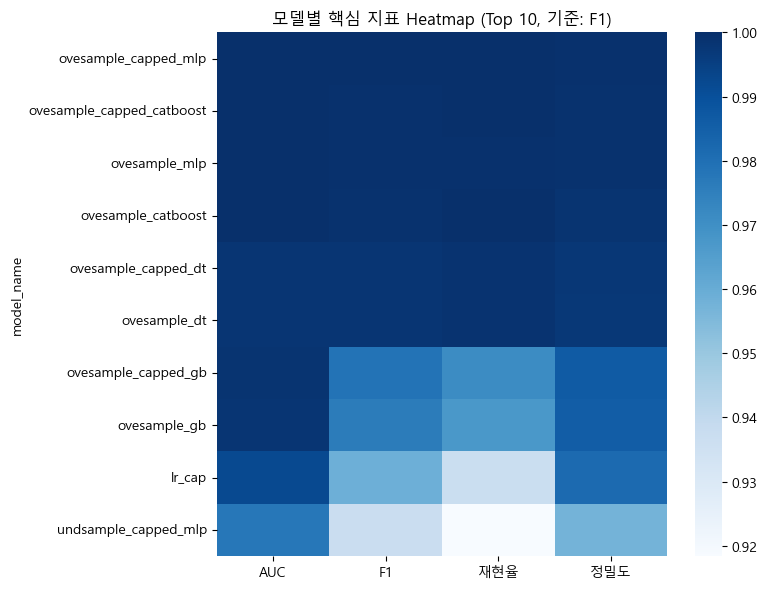

🔥 Heatmap 저장 완료 → ../report/metric_heatmap.png
🔥 Heatmap 생성 완료

=== 지표별 통계 요약 ===

[AUC]
  최고  : 1.0000 (0)
  최저  : 0.0000 (74)
  평균  : 0.9169
  표준편차 : 0.1716

[정밀도]
  최고  : 0.9994 (0)
  최저  : 0.0000 (176)
  평균  : 0.4641
  표준편차 : 0.3685

[재현율]
  최고  : 1.0000 (0)
  최저  : 0.0000 (176)
  평균  : 0.8130
  표준편차 : 0.1654

[F1]
  최고  : 0.9997 (0)
  최저  : 0.0000 (176)
  평균  : 0.4792
  표준편차 : 0.3313


,file_name,AUC,정확도,정밀도,재현율,F1,F2,실행시간
model_name,,,,,,,,
ovesample_capped_mlp,ovesample_capped_mlp_ejm_20251127.txt,1.0000,0.9997,0.9994,1.0000,0.9997,NaN,NaN
ovesample_capped_catboost,ovesample_capped_catboost_ejm_20251127.txt,1.0000,0.9995,0.9991,1.0000,0.9995,NaN,NaN
ovesample_mlp,ovesample_mlp_ejm_20251127.txt,1.0000,0.9994,0.9991,0.9996,0.9994,NaN,NaN
ovesample_catboost,ovesample_catboost_ejm_20251127.txt,1.0000,0.9992,0.9985,1.0000,0.9992,NaN,NaN
ovesample_capped_dt,ovesample_capped_dt_ejm_20251127.txt,0.9982,0.9983,0.9975,0.9990,0.9983,NaN,NaN
ovesample_dt,ovesample_dt_ejm_20251127.txt,0.9982,0.9982,0.9974,0.9990,0.9982,NaN,NaN
ovesample_capped_gb,ovesample_capped_gb_ejm_20251127.txt,0.9985,0.9788,0.9863,0.9713,0.9787,NaN,NaN
ovesample_gb,ovesample_gb_ejm_20251127.txt,0.9983,0.9766,0.9857,0.9674,0.9764,NaN,NaN
lr_cap,lr_cap_over_20251128.txt,0.9921,0.9597,0.9816,0.9371,0.9588,NaN,NaN


In [80]:
model_metrics_graph4CCF(
    df_results,
    top_n=10,
    sort_by="F1",
    output_dir="../report",
    create_top10=True,
    create_boxplot=True,
    create_radar=True,
    create_heatmap=True
)
